# Model 1 – K-Means Clustering


## 1. Model Description

**Basic Idea of K-Means**

K-Means is an unsupervised learning algorithm used to group similar data points into clusters.

**Working principle:**

* Choose number of clusters (K)
* Randomly initialize K centroids
* Assign each data point to the nearest centroid
* Recalculate centroids (mean of cluster points)
* Repeat until centroids stop changing (convergence)

**Objective:**

* Minimize intra-cluster distance (within cluster)
* Maximize inter-cluster separation

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
df = pd.read_excel(r'C:\Users\abhib\Desktop\ExcelR\clustering_world_development\data\scaled_world_development_data.xlsx')

In [89]:
df.head()

,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,...,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound,Country
0,1.870190,-0.320453,-0.223769,-0.605350,-0.200725,-0.221223,1.001363,-0.507925,-0.072665,1.818801,...,-0.875795,0,1.859193,-2.083215,-1.071522,-0.048792,-1.352068,-0.311498,-0.313712,Afghanistan
1,-0.718942,-0.146491,-0.221150,-0.318682,-0.255672,-0.222389,-0.100614,-0.422879,0.295412,-0.490754,...,-0.036655,0,-0.439928,0.438224,0.340809,-0.229545,-0.345742,-0.255474,-0.254368,Albania
2,-0.047167,0.720882,-0.051376,-0.274916,-0.112798,-0.118438,-1.087114,-0.449167,0.651150,-0.135438,...,-0.252434,0,-0.099826,0.581701,-0.578096,0.026606,0.336908,-0.326626,-0.301839,Algeria
3,-0.229106,-0.189633,-0.213210,-0.253033,-0.200725,-0.216553,-0.120410,-0.404737,-0.220718,-0.411491,...,-0.827844,0,-0.032339,0.267109,-0.414699,-0.252897,1.299111,-0.293587,-0.301438,American Samoa
4,-1.026838,-0.189633,-0.226923,-0.253033,-0.200725,-0.224923,-0.024729,1.248741,-0.220718,-1.015529,...,0.394903,0,-0.032339,0.267109,-0.414699,-0.252742,1.370654,-0.293587,-0.301438,Andorra


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              208 non-null    float64
 1   Business Tax Rate       208 non-null    float64
 2   CO2 Emissions           208 non-null    float64
 3   Days to Start Business  208 non-null    float64
 4   Energy Usage            208 non-null    float64
 5   GDP                     208 non-null    float64
 6   Health Exp % GDP        208 non-null    float64
 7   Health Exp/Capita       208 non-null    float64
 8   Hours to do Tax         208 non-null    float64
 9   Infant Mortality Rate   208 non-null    float64
 10  Internet Usage          208 non-null    float64
 11  Lending Interest        208 non-null    float64
 12  Life Expectancy Female  208 non-null    float64
 13  Life Expectancy Male    208 non-null    float64
 14  Mobile Phone Usage      208 non-null    fl

## 2. Hyperparameter Tuning

* Number of clusters (K)
* Initialization method
* Number of iterations

**Methods used:**
* Elbow Method
* Silhouette Analysis

In [91]:
# Drop categorical column (Country)
X = df.drop(columns=['Country', 'Number of Records'])

In [92]:
X.columns

Index(['Birth Rate', 'Business Tax Rate', 'CO2 Emissions',
       'Days to Start Business', 'Energy Usage', 'GDP', 'Health Exp % GDP',
       'Health Exp/Capita', 'Hours to do Tax', 'Infant Mortality Rate',
       'Internet Usage', 'Lending Interest', 'Life Expectancy Female',
       'Life Expectancy Male', 'Mobile Phone Usage', 'Population 0-14',
       'Population 15-64', 'Population 65+', 'Population Total',
       'Population Urban', 'Tourism Inbound', 'Tourism Outbound'],
      dtype='object')

### Dimensionality Reduction with PCA:

In [93]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X)

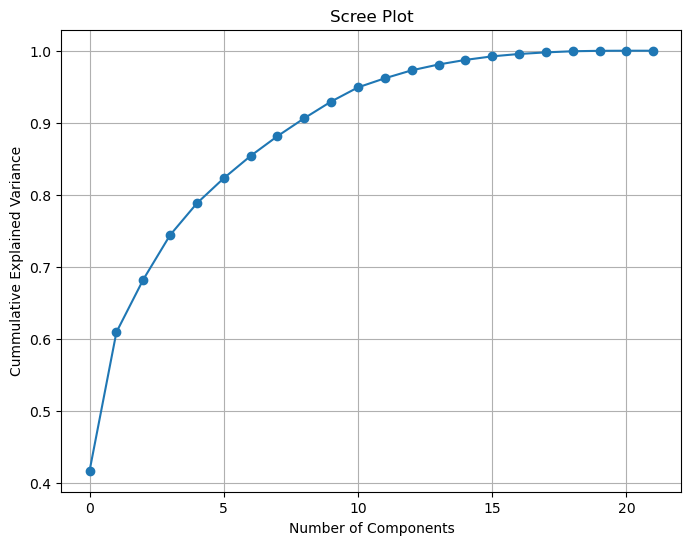

In [94]:
# Determine Optimal no. of components

plt.figure(figsize=(8,6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cummulative Explained Variance')
plt.title('Scree Plot')
plt.grid()
plt.show()

In [95]:
np.cumsum(pca.explained_variance_ratio_)

array([0.41638843, 0.60890627, 0.68200559, 0.74386268, 0.78804436,
       0.82287047, 0.853841  , 0.8812934 , 0.90621139, 0.92938536,
       0.94906027, 0.96169354, 0.97275011, 0.98084769, 0.98722541,
       0.99218729, 0.99546578, 0.99769005, 0.99927432, 0.99987325,
       0.99999524, 1.        ])

Since the first 10 principal components explain approximately 92.93% of the total variance, we reduce the dataset from 22 features to 10 components while preserving most of the information.

In [96]:
# Apply PCA with 10 Components

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X)

print('Original Shape: ', X.shape)
print('Shape after PCA: ', X_pca.shape)

Original Shape:  (208, 22)
Shape after PCA:  (208, 10)


Based on the cumulative explained variance analysis, the first 10 principal components account for approximately 92% of the total variance in the dataset. Therefore, the dimensionality of the dataset was reduced from 22 original features to 10 principal components. This reduction significantly decreases feature redundancy while retaining most of the meaningful information present in the data.

### 1. Elbow Method:

In [97]:
import warnings
warnings.filterwarnings('ignore')

In [98]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []

k_range = range(2,11)  # testing K from 2 to 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, 
                    init='k-means++', 
                    max_iter=300,
                    random_state=42
                   )
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

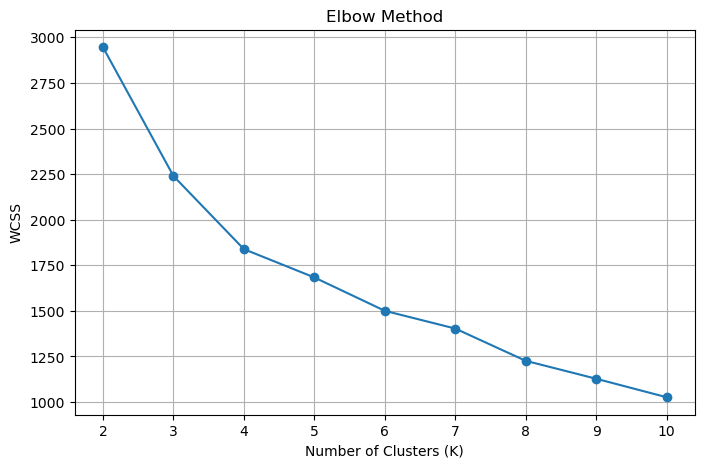

In [99]:
# Plot Elbow Graph

plt.figure(figsize=(8,5))
plt.plot(k_range, wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(k_range)
plt.grid()
plt.show()

The Elbow curve shows a sharp decrease in WCSS from K = 2 to K = 4, after which the reduction becomes gradual.

This indicates that the optimal number of clusters lies around K = 3 or K = 4, where adding more clusters does not significantly improve the model.

### 2. Silhouette Analysis

In [100]:
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        max_iter=300,
        random_state=42
    )
    labels = kmeans.fit_predict(X_pca)
    
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)

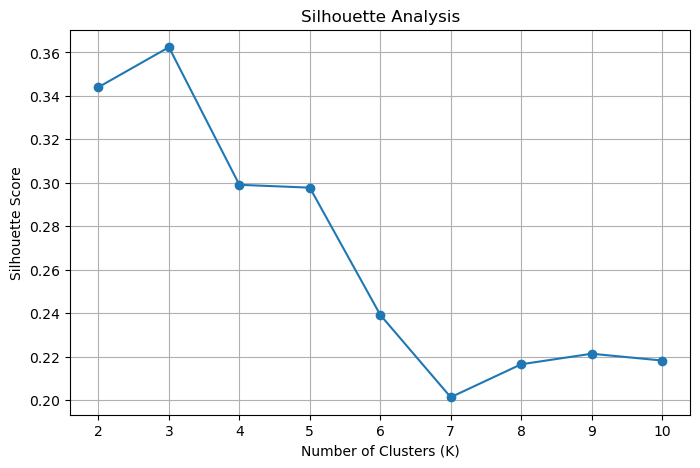

In [101]:
# Plot Silhouette Scores
plt.figure(figsize=(8,5))
plt.plot(k_range, silhouette_scores, marker='o')
plt.title("Silhouette Analysis")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(k_range)
plt.grid()
plt.show()

In [102]:
## 3. Best K Selection
# -------------------------------
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]

print("Best K based on Silhouette Score:", best_k)

Best K based on Silhouette Score: 3


The Silhouette Score is highest at K = 3, indicating well-separated clusters. 

Based on hyperparameter tuning, the Elbow Method suggested an optimal range of K = 3 to 4, while Silhouette Analysis showed the highest score at K = 3. K = 3 was selected as the final number of clusters as it provides a good balance between cluster separation and interpretability, enabling more meaningful segmentation of countries into distinct development groups.

## 3. Model Training

* Fit model with optimal parameters

In [103]:
from sklearn.cluster import KMeans

optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    max_iter=300,
    random_state=42
)

# Fit the model
kmeans.fit(X_pca)

# Get cluster labels
labels = kmeans.labels_

# Add cluster labels to original dataset
df['Cluster'] = labels

df.head()

,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,...,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound,Country,Cluster
0,1.870190,-0.320453,-0.223769,-0.605350,-0.200725,-0.221223,1.001363,-0.507925,-0.072665,1.818801,...,0,1.859193,-2.083215,-1.071522,-0.048792,-1.352068,-0.311498,-0.313712,Afghanistan,0
1,-0.718942,-0.146491,-0.221150,-0.318682,-0.255672,-0.222389,-0.100614,-0.422879,0.295412,-0.490754,...,0,-0.439928,0.438224,0.340809,-0.229545,-0.345742,-0.255474,-0.254368,Albania,1
2,-0.047167,0.720882,-0.051376,-0.274916,-0.112798,-0.118438,-1.087114,-0.449167,0.651150,-0.135438,...,0,-0.099826,0.581701,-0.578096,0.026606,0.336908,-0.326626,-0.301839,Algeria,1
3,-0.229106,-0.189633,-0.213210,-0.253033,-0.200725,-0.216553,-0.120410,-0.404737,-0.220718,-0.411491,...,0,-0.032339,0.267109,-0.414699,-0.252897,1.299111,-0.293587,-0.301438,American Samoa,1
4,-1.026838,-0.189633,-0.226923,-0.253033,-0.200725,-0.224923,-0.024729,1.248741,-0.220718,-1.015529,...,0,-0.032339,0.267109,-0.414699,-0.252742,1.370654,-0.293587,-0.301438,Andorra,1


In [104]:
# Count of countries in each cluster
df['Cluster'].value_counts()

Cluster
1    125
0     81
2      2
Name: count, dtype: int64

In [105]:
# Centroids of clusters
centroids = kmeans.cluster_centers_
print(centroids)

[[ 3.03893943e+00  7.17811130e-01  2.17007215e-01 -9.95988490e-02
  -1.58574646e-01  3.25174522e-02 -6.42384567e-02 -5.28803368e-02
   7.68734799e-02 -2.95665348e-02]
 [-1.82511434e+00 -7.29088437e-01 -9.46259433e-02  8.56496507e-02
   1.03098891e-01 -1.91212788e-02  4.67012024e-02  2.56758591e-02
  -4.72422453e-02  7.00019261e-03]
 [-9.00740073e+00  1.64966766e+01 -2.87467075e+00 -1.31934979e+00
  -2.14075109e-02 -1.21876893e-01 -3.17167652e-01  5.36912444e-01
  -1.60735606e-01  7.59932623e-01]]


The K-Means clustering model was trained using the optimal number of clusters (K = 3) identified during hyperparameter tuning. The model used k-means++ initialization to ensure better centroid selection and convergence, with a maximum of 300 iterations. After fitting the model, each data point (country) was assigned to a cluster, enabling segmentation based on development indicators.

## 4. Evaluation

* Silhouette Score
* Cluster visualization
* Interpretation of clusters

In [106]:
from sklearn.metrics import silhouette_score

# Calculate silhouette score
sil_score = silhouette_score(X_pca, df['Cluster'])

print("Silhouette Score:", sil_score)

Silhouette Score: 0.3624079757913549


* The score (~0.36) indicates moderate cluster separation
* Clusters are reasonably well-formed, though not perfectly distinct
* Some overlap exists, which is expected in real-world datasets

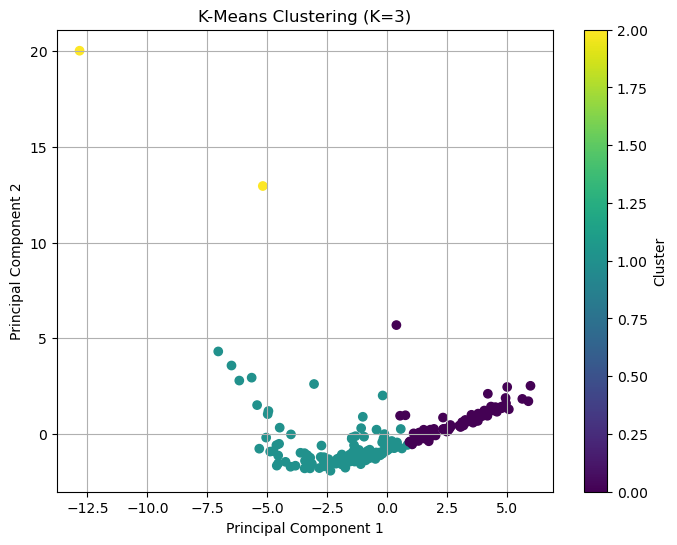

In [107]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'])
plt.title("K-Means Clustering (K=3)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Cluster')
plt.grid()
plt.show()

* The plot shows three distinct clusters, represented by different colors
* Cluster 0 (purple):
    * Clearly separated on the right side
    * Indicates a group of countries with similar strong characteristics
* Cluster 2 (yellow):
    * Dense grouping in the center
    * Represents the majority of countries with moderate values
* Cluster 1 (green):
    * Spread out on the left side with some dispersion
    * Indicates a distinct group with different development patterns

**Overall Observations:**

* Clusters are visibly separable, especially Cluster 0
* Some overlap exists between Cluster 1 and Cluster 2
* A few outliers are visible (extreme points), which is normal

In [108]:
# Interpretation of clusters

# Make sure Country column exists with clusters
df_with_country = df.copy()

In [109]:
cluster_profile = df_with_country.groupby('Cluster').mean(numeric_only=True)

cluster_profile

,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1.036433,0.257998,-0.160652,0.372524,-0.157385,-0.195848,-0.250346,-0.486829,0.061381,1.004543,...,-0.969252,-0.906874,0.0,1.032850,-1.030090,-0.764002,0.028713,-0.807468,-0.296736,-0.290446
1,-0.657698,-0.172262,-0.047809,-0.236244,-0.046475,0.002829,0.134246,0.281602,-0.046739,-0.640490,...,0.615037,0.588624,0.0,-0.653829,0.650993,0.484832,-0.118135,0.519518,0.085190,0.096969
2,-0.869391,0.317465,9.494440,-0.321965,9.278787,7.755015,1.748661,2.116443,0.435239,-0.653380,...,0.814934,-0.060630,0.0,-0.966095,1.031538,0.640101,6.220550,0.232588,6.693416,5.702506


In [110]:
# Cluster Size 

df_with_country['Cluster'].value_counts()

Cluster
1    125
0     81
2      2
Name: count, dtype: int64

In [111]:
# Transpose for better readability
cluster_profile.T

Cluster,0,1,2
Birth Rate,1.036433,-0.657698,-0.869391
Business Tax Rate,0.257998,-0.172262,0.317465
CO2 Emissions,-0.160652,-0.047809,9.494440
Days to Start Business,0.372524,-0.236244,-0.321965
Energy Usage,-0.157385,-0.046475,9.278787
GDP,-0.195848,0.002829,7.755015
Health Exp % GDP,-0.250346,0.134246,1.748661
Health Exp/Capita,-0.486829,0.281602,2.116443
Hours to do Tax,0.061381,-0.046739,0.435239
Infant Mortality Rate,1.004543,-0.640490,-0.653380


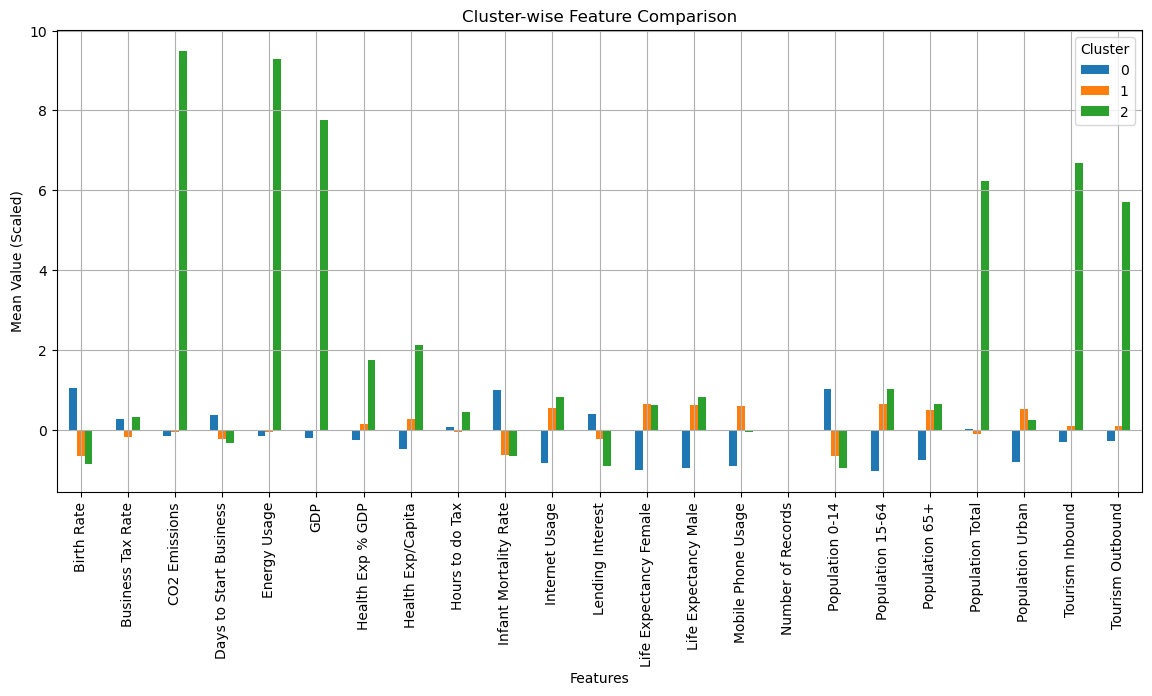

In [112]:
# Visualize Cluster Profiles (Bar Plot)

# Plot cluster means
cluster_profile.T.plot(kind='bar', figsize=(14,6))
plt.title("Cluster-wise Feature Comparison")
plt.xlabel("Features")
plt.ylabel("Mean Value (Scaled)")
plt.xticks(rotation=90)
plt.legend(title='Cluster')
plt.grid()
plt.show()

In [113]:
# Identify Top Features per Cluster

for i in range(3):
    print(f"\nCluster {i} Top Features:")
    print(cluster_profile.loc[i].sort_values(ascending=False).head(5))


Cluster 0 Top Features:
Birth Rate                1.036433
Population 0-14           1.032850
Infant Mortality Rate     1.004543
Lending Interest          0.392755
Days to Start Business    0.372524
Name: 0, dtype: float64

Cluster 1 Top Features:
Population 15-64          0.650993
Life Expectancy Female    0.641219
Life Expectancy Male      0.615037
Mobile Phone Usage        0.588624
Internet Usage            0.533923
Name: 1, dtype: float64

Cluster 2 Top Features:
CO2 Emissions       9.494440
Energy Usage        9.278787
GDP                 7.755015
Tourism Inbound     6.693416
Population Total    6.220550
Name: 2, dtype: float64


In [114]:
# View Countries in Each Cluster

for i in range(3):
    print(f"\nCluster {i} Countries:")
    print(df_with_country[df_with_country['Cluster'] == i]['Country'].values[:10])  # first 10


Cluster 0 Countries:
['Afghanistan' 'Angola' 'Bangladesh' 'Belize' 'Benin' 'Bhutan' 'Bolivia'
 'Botswana' 'Burkina Faso' 'Burundi']

Cluster 1 Countries:
['Albania' 'Algeria' 'American Samoa' 'Andorra' 'Antigua and Barbuda'
 'Argentina' 'Armenia' 'Aruba' 'Australia' 'Austria']

Cluster 2 Countries:
['China' 'United States']


## 5. Cluster Interpretation & Labeling

### Cluster 0 : Underdeveloped Countries

**Key Characteristics:**
* High Birth Rate 
* High Infant Mortality Rate 
* High Young Population (0–14) 
* Low GDP & Energy Usage 
* Low Internet & Mobile Usage 
* Low Life Expectancy 
* Higher Lending Interest Rates  

**Example Countries:**

Afghanistan, Angola, Bangladesh, Benin, Burkina Faso

**Interpretation:**

Countries in this cluster have:

* Have weak economic conditions
* Face healthcare challenges
* Show high population growth
* Have limited technological penetration


### Cluster 1 :  Developing Countries

**Key Characteristics:**
* Moderate GDP and economic indicators
* Improved Life Expectancy (Male & Female) 
* Higher Internet & Mobile Usage 
* Balanced Working Population (15–64) 
* Moderate urbanization

**Example Countries:**

Albania, Algeria, Argentina, Armenia, Australia

**Interpretation:**

Countries in this cluster have:

* Are in a growth and transition phase
* Show improving infrastructure and healthcare
* Have increasing digital adoption

### Cluster 2 → Highly Developed Countries

**Key Characteristics:**

* Extremely High GDP 
* Very High Energy Usage & CO₂ Emissions 
* Very High Tourism (Inbound & Outbound) 
* Very Large Population 
* Strong Economic Activity Indicators

**Example Countries:**

China, United States

**Interpretation:**

Countries in this cluster are:

* Global economic leaders
* Countries with massive industrial output
* High consumption and global influence

## Save K-Means Model

In [115]:
import joblib

# Save trained model
joblib.dump(kmeans, "kmeans_model.pkl")

['kmeans_model.pkl']

In [116]:
# Save feature columns
joblib.dump(X.columns.tolist(), "features.pkl")

['features.pkl']

We saved the trained K-Means model using joblib and reused it in another notebook to ensure consistent and fair comparison with other clustering models